

## Business Quetions

1) Which city has the highest number of flights departing from it?

2) What is the heighest price according to departuretime?

3) Find the N.of stops for the departure_time?

4) Find maximum Number of stops for departuretime(Night)?

5) Is the price affected by destination city?

6) How is the affect between the number of stops and the flight duration?

7) What is the maximum & minimum price for Economic class?

8) What is the maximum & minimum price for Business class?

9) What is the arrival time of Delhi?

10) How is the price affected when tickets are bought in just 1 or 2 days before departure?

11) How is the price affected by Arrial time ?

12) Which airline has the highest average ticket price?

13) What is the average of price for Destination & Source city?

14) Which source city and destination city combination has the highest number of flight bookings?

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
df = pd.read_csv('/content/drive/MyDrive/Pandas Data/Flight_Dataset.csv')
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [61]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [63]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,300153.0,NaN,NaN,NaN,150076.0,86646.852011,0.0,75038.0,150076.0,225114.0,300152.0
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,300153.0,NaN,NaN,NaN,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83


In [64]:
df.drop(columns='Unnamed: 0',inplace=True)

In [65]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

1) Which city has the highest number of flights departing from it?

In [66]:
counts = df['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64


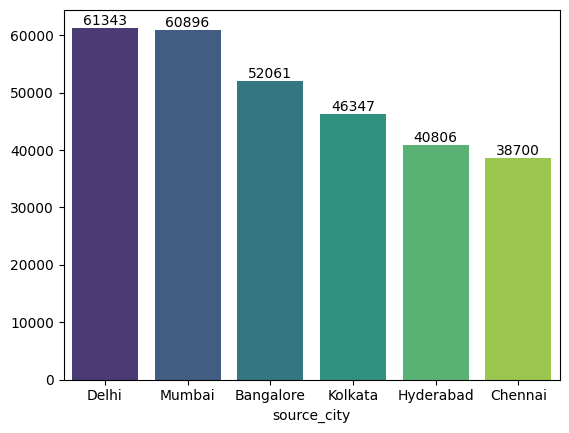

In [67]:
print(counts)
sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index)
for i, count in enumerate(counts):
    plt.text(i,count,str(count),ha='center',va='bottom')

2) What is the heighest price according to departuretime?

In [68]:
highest_price = df.groupby('departure_time')['price'].mean()
highest_price

,price
departure_time,
Afternoon,18179.203331
Early_Morning,20370.676718
Evening,21232.361894
Late_Night,9295.299387
Morning,21630.760254
Night,23062.146808


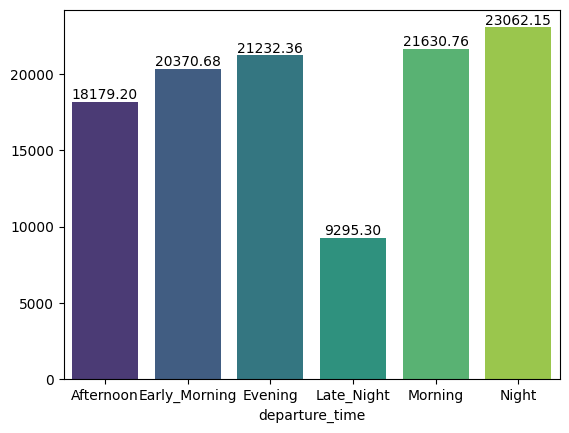

In [69]:
sns.barplot(x=highest_price.index, y=highest_price.values, palette='viridis', hue=highest_price.index)
for i, count in enumerate(highest_price):
    plt.text(i,count,f"{count:.2f}",ha='center',va='bottom')

3) Find the N.of stops for the departure_time?
4) Find maximum Number of stops for departuretime(Night)?

In [70]:
df['stops'].value_counts()

,count
stops,
one,250863
zero,36004
two_or_more,13286


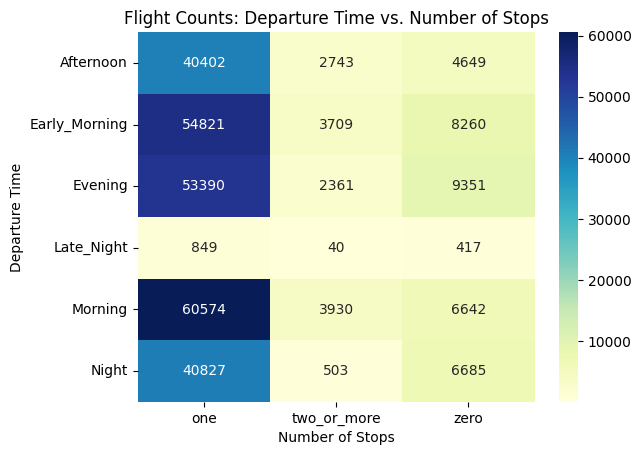

In [71]:

pivot_table = df.groupby(['departure_time', 'stops']).size().unstack(fill_value=0)
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Flight Counts: Departure Time vs. Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Departure Time')
plt.show()

5) Is the price affected by destination city?

In [72]:
price_aft = df.groupby('destination_city')['price'].mean().round(2)
price_aft

,price
destination_city,
Bangalore,21593.96
Chennai,21953.32
Delhi,18436.77
Hyderabad,20427.66
Kolkata,21959.56
Mumbai,21372.53


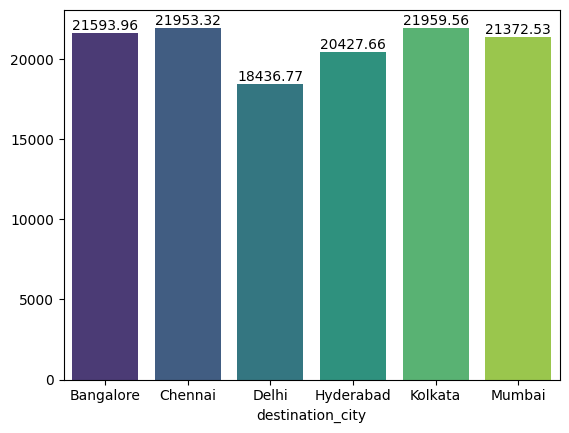

In [73]:
sns.barplot(x=price_aft.index, y=price_aft.values, palette='viridis', hue=price_aft.index)
for i, count in enumerate(price_aft):
    plt.text(i,count,f"{count:.2f}",ha='center',va='bottom')

6) How is the affect between the number of stops and the flight duration?


In [74]:
stops_aft = df.groupby('stops')['duration'].mean()
stops_aft

,duration
stops,
one,13.496514
two_or_more,15.317141
zero,2.191324


7) What is the maximum & minimum price for Economic class?



In [75]:
max_eco_price = df.groupby('class')['price'].max()
min_eco_price = df.groupby('class')['price'].min()

print('Maximum Price of An Economy Class is ', max_eco_price[1:])
print('Minimum Price of An Economy Class is ', min_eco_price[1:])

Maximum Price of An Economy Class is  class
Economy    42349
Name: price, dtype: int64
Minimum Price of An Economy Class is  class
Economy    1105
Name: price, dtype: int64


8) What is the maximum & minimum price for Business class?

In [76]:
print('Maximum Price of An Business Class is ', max_eco_price[:1])
print('Minimum Price of An Business Class is ', min_eco_price[:1])

Maximum Price of An Business Class is  class
Business    123071
Name: price, dtype: int64
Minimum Price of An Business Class is  class
Business    12000
Name: price, dtype: int64


9) What is the arrival time of Delhi?

In [77]:
s = df[df['source_city']=='Delhi'].groupby('arrival_time').size()
s

,0
arrival_time,
Afternoon,8007
Early_Morning,5262
Evening,14630
Late_Night,2143
Morning,13007
Night,18294


10) How is the price affected when tickets are bought in just 1 or 2 days before departure?

<Axes: xlabel='days_left'>

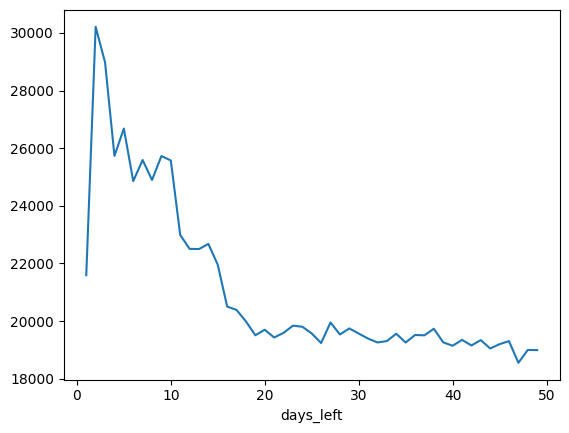

In [78]:
df.groupby('days_left')['price'].mean().round(2).plot(kind='line')


11) How is the price affected by Arrival time ?

<Axes: ylabel='arrival_time'>

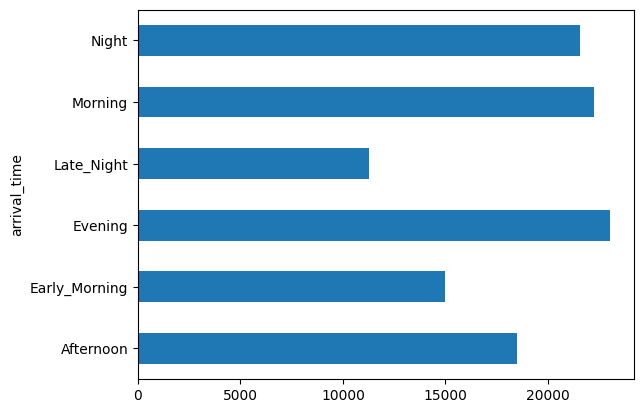

In [79]:
df.groupby('arrival_time')['price'].mean().round(2).plot(kind='barh')

12) Which airline has the highest average ticket price?

In [80]:
airline_avg_price = df.groupby('airline')['price'].mean().round(2)
airline_avg_price

,price
airline,
AirAsia,4091.07
Air_India,23507.02
GO_FIRST,5652.01
Indigo,5324.22
SpiceJet,6179.28
Vistara,30396.54


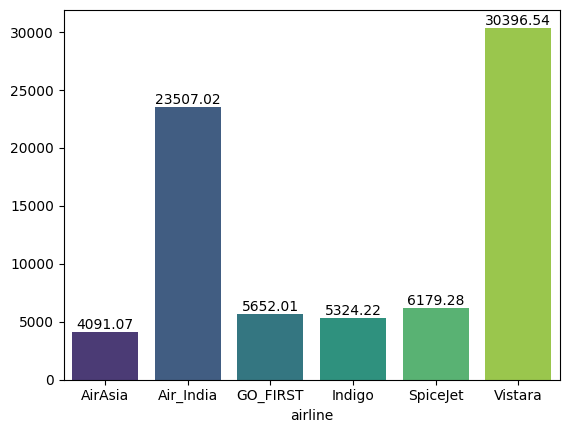

In [81]:
sns.barplot(x=airline_avg_price.index, y=airline_avg_price.values, palette='viridis', hue=airline_avg_price.index)
for i, count in enumerate(airline_avg_price):
    plt.text(i,count,f"{count:.2f}",ha='center',va='bottom')

13) What is the average of price for Destination & Source city?

In [82]:
avg_price_dest_sour = df.pivot_table(
                                values = 'price',
                                index = 'source_city',
                                columns = 'destination_city',
                                aggfunc = 'mean'
                                )
avg_price_dest_sour

destination_city,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
source_city,,,,,,
Bangalore,NaN,23321.850078,17723.313972,21226.121192,23500.061229,23128.618672
Chennai,25081.850454,NaN,18981.863948,21591.345404,22669.932407,22765.849647
Delhi,17880.216315,19369.881354,NaN,17347.288379,20566.409418,19355.829812
Hyderabad,21347.177998,21848.065989,17243.945685,NaN,20823.893201,20080.865759
Kolkata,22744.808428,23660.361040,19422.354559,21500.011397,NaN,22078.883579
Mumbai,23147.873807,22781.899112,18725.320008,21004.046705,22379.146723,NaN


<Axes: xlabel='destination_city', ylabel='source_city'>

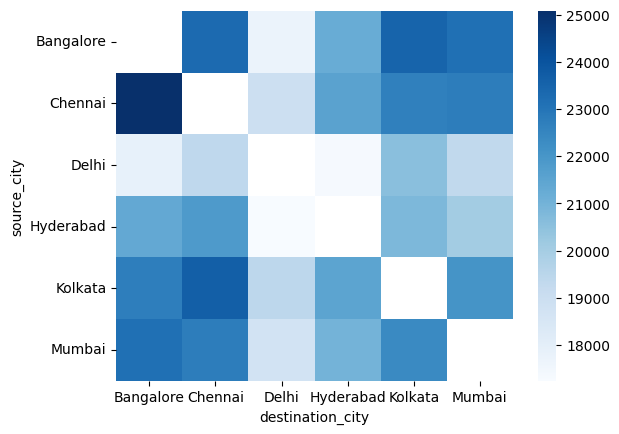

In [83]:
sns.heatmap(avg_price_dest_sour,cmap='Blues')

14) Which source city and destination city combination has the highest number of flight bookings?

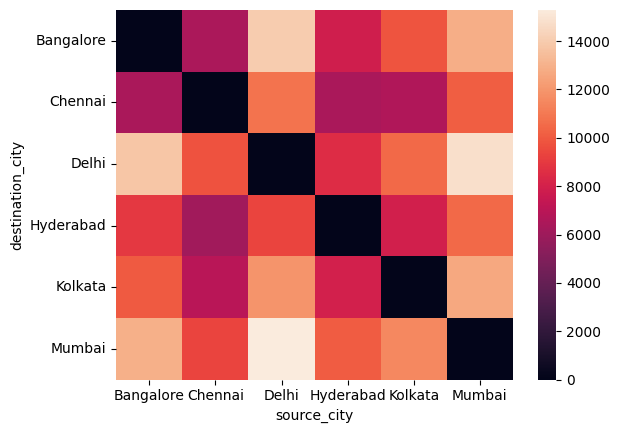

In [84]:
high_price_dest_sour = df.groupby(['destination_city', 'source_city']).size().unstack(fill_value=0)
sns.heatmap(high_price_dest_sour)
plt.show()

In [85]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


<Axes: xlabel='duration', ylabel='price'>

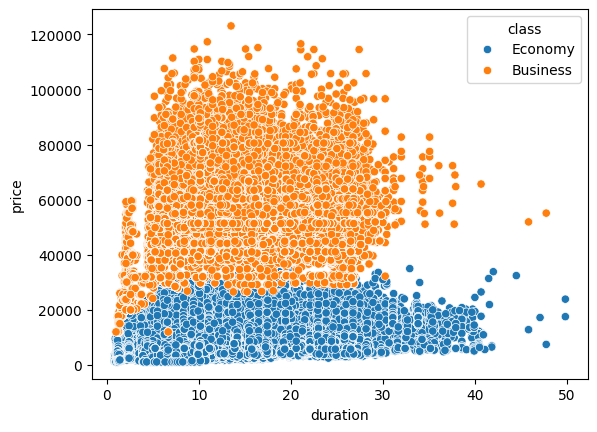

In [86]:
sns.scatterplot(x='duration',y='price',data = df,hue='class')

Let's ML Part

In [87]:
df= df.drop(columns='flight')

In [88]:
df['days_left'].value_counts().sort_values()

,count
days_left,
1,1927
2,4026
3,4248
4,5077
5,5392
9,5665
7,5703
6,5740
8,5767


In [89]:
df['weeks'] = (df['days_left'] // 7) + 1

In [90]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,weeks
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1


In [91]:
df['class'] = df['class'].map({'Economy':0, 'Business':1})
df['stops'] = df['stops'].map({'zero':0,'one':1,'two_or_more':2})

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error

In [93]:
x = df.drop(columns='price')
y = df['price']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

In [95]:
X_train

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,weeks
148417,Air_India,Kolkata,Afternoon,1,Morning,Chennai,0,19.42,6,1
36879,Indigo,Delhi,Afternoon,2,Night,Chennai,0,7.00,13,2
274531,Air_India,Kolkata,Afternoon,1,Afternoon,Chennai,1,21.17,44,7
166397,Vistara,Hyderabad,Night,1,Early_Morning,Bangalore,0,10.25,11,2
272722,Vistara,Kolkata,Night,1,Night,Chennai,1,26.50,5,1
...,...,...,...,...,...,...,...,...,...,...
119879,Vistara,Kolkata,Evening,1,Afternoon,Delhi,0,20.50,2,1
259178,Vistara,Bangalore,Night,1,Night,Chennai,1,25.42,7,2
131932,Air_India,Kolkata,Night,1,Morning,Mumbai,0,13.67,29,5
146867,GO_FIRST,Kolkata,Afternoon,1,Night,Hyderabad,0,8.33,39,6


In [96]:
X_test

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,weeks
27131,Air_India,Delhi,Morning,1,Early_Morning,Kolkata,0,19.75,40,6
266857,Vistara,Kolkata,Morning,1,Night,Mumbai,1,9.83,42,7
141228,Vistara,Kolkata,Morning,1,Night,Bangalore,0,10.50,41,6
288329,Vistara,Chennai,Night,1,Morning,Delhi,1,14.50,14,3
97334,Air_India,Bangalore,Afternoon,1,Night,Mumbai,0,8.25,20,3
...,...,...,...,...,...,...,...,...,...,...
5234,Air_India,Delhi,Early_Morning,1,Evening,Mumbai,0,12.58,27,4
5591,Indigo,Delhi,Evening,0,Night,Mumbai,0,2.17,29,5
168314,Air_India,Hyderabad,Early_Morning,1,Night,Bangalore,0,13.58,28,5
175191,Indigo,Hyderabad,Evening,0,Evening,Kolkata,0,2.00,40,6


In [97]:
transformer = ColumnTransformer(transformers = [
    ('OHE',OneHotEncoder(sparse_output = False, drop = 'first'),['source_city','destination_city','airline','departure_time','arrival_time'])
],remainder='passthrough')

In [98]:
std_scaler = StandardScaler()

In [99]:
lr = LinearRegression()

In [100]:
dt = DecisionTreeRegressor()

In [101]:
rfr = RandomForestRegressor()

In [102]:
pipe_lr = Pipeline([
    ('OHE',transformer),
    ('std',std_scaler),
    ('model_lr',lr)
])

In [103]:
pipe_lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['source_city',
                                                   'destination_city',
                                                   'airline', 'departure_time',
                                                   'arrival_time'])])),
                ('std', StandardScaler()), ('model_lr', LinearRegression())])

In [104]:
pipe_dt = Pipeline([
    ('OHE',transformer),
    ('std',std_scaler),
    ('model_dt',dt)
])

In [105]:
pipe_dt.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['source_city',
                                                   'destination_city',
                                                   'airline', 'departure_time',
                                                   'arrival_time'])])),
                ('std', StandardScaler()),
                ('model_dt', DecisionTreeRegressor())])

In [106]:
pipe_rfr = Pipeline([
    ('OHE',transformer),
    ('std',std_scaler),
    ('model_rfr',rfr)
])

In [107]:
pipe_rfr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['source_city',
                                                   'destination_city',
                                                   'airline', 'departure_time',
                                                   'arrival_time'])])),
                ('std', StandardScaler()),
                ('model_rfr', RandomForestRegressor())])

In [117]:
score = {
    'Linear Model': pipe_lr,
    'Decision Tree': pipe_dt,
    'Random Regressor': pipe_rfr
}
print(f"{'Model':<25} {'MAE':>10} {'MSE':>10} {'RMSE':>12} {'Test R2':>12} {'Train R2':>12}")
for name, pipe in score.items():
  mae = mean_absolute_error(y_test, pipe.predict(X_test))
  mse = mean_squared_error(y_test ,pipe.predict(X_test))
  rmse = root_mean_squared_error(y_test, pipe.predict(X_test))
  test_R2 = r2_score(y_test,pipe.predict(X_test))
  train_R2 = r2_score(y_train,pipe.predict(X_train))
  print(f'{name:<25} {mae:>10.2f} {mse:>10.2f} {rmse:>12.2f} {test_R2:>12.2f} {train_R2:>12.2f}')

Model                            MAE        MSE         RMSE      Test R2     Train R2
Linear Model                 4499.13 46424354.69      6813.54         0.91         0.91
Decision Tree                1184.99 12694280.26      3562.90         0.98         1.00
Random Regressor             1088.93 7854041.80      2802.51         0.98         1.00


In [109]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe_rfr, X_train, y_train, cv=5, scoring='r2')

In [110]:
scores

array([0.98482096, 0.98482193, 0.98526276, 0.98483595, 0.98542566])

In [111]:
print("CV Scores:", scores)
print("Mean R²:", scores.mean().round(4))
print("Std:", scores.std().round(4))

CV Scores: [0.98482096 0.98482193 0.98526276 0.98483595 0.98542566]
Mean R²: 0.985
Std: 0.0003


In [112]:
y_pred = pipe_rfr.predict(X_test)
print("Test R²:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 2))

Test R²: 0.9848
MAE: 1088.93
RMSE: 2802.51


<Axes: xlabel='Importance', ylabel='Feature'>

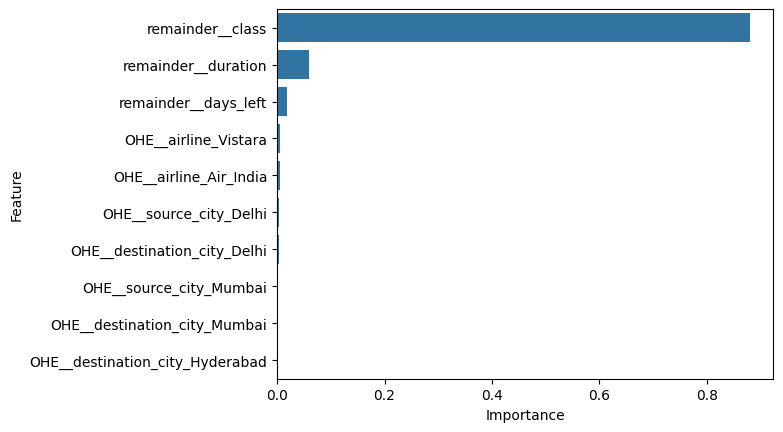

In [113]:
# Extract Random Forest from pipeline
rf_model = pipe_rfr.named_steps['model_rfr']
feature_names = pipe_rfr.named_steps['OHE'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))

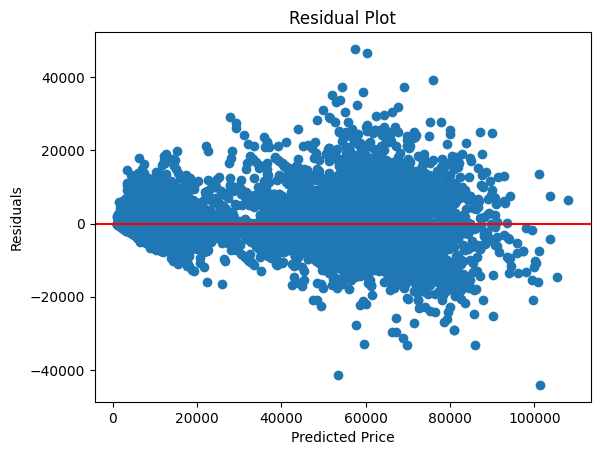

In [114]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()